## 1. import package and data

In [41]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

In [3]:
# Get the current working directory
folder_path = os.getcwd()  # This gets the current directory where the script is running

# Get all CSV file paths in the current directory
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read each CSV file and store it in a dictionary with the filename as the key
dataframes = {}
for file in csv_files:
    file_name = os.path.basename(file).replace(".csv", "")  # Extract filename without extension
    dataframes[file_name] = pd.read_csv(file)

# Display loaded dataframes
for name, df in dataframes.items():
    print(f"DataFrame Name: {name}")


/var/folders/cy/nlx8jpzj6q5fxs1wszrs2wjr0000gn/T/ipykernel_16254/1630922233.py:11: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[file_name] = pd.read_csv(file)


DataFrame Name: constituents
DataFrame Name: published_images
DataFrame Name: media_items
DataFrame Name: media_relationships
DataFrame Name: object_associations
DataFrame Name: constituents_text_entries
DataFrame Name: objects_constituents
DataFrame Name: objects_terms
DataFrame Name: objects
DataFrame Name: constituents_altnames
DataFrame Name: objects_dimensions
DataFrame Name: locations
DataFrame Name: alternative_identifiers
DataFrame Name: preferred_locations_tms_locations
DataFrame Name: objects_historical_data
DataFrame Name: preferred_locations
DataFrame Name: objects_text_entries


## 2. check nulls

In [4]:
dataframes.get('objects').isnull().sum()

objectid                            0
accessioned                         0
accessionnum                        0
locationid                     138781
title                               0
displaydate                     12217
beginyear                         458
endyear                           469
visualbrowsertimespan             458
medium                           1246
dimensions                      28120
inscription                     60616
markings                       127750
attributioninverted                 1
attribution                         1
provenancetext                  65459
creditline                         25
classification                      0
subclassification              105320
visualbrowserclassification         0
parentid                       115033
isvirtual                           0
departmentabbr                      0
portfolio                      101047
series                         103113
volume                         139132
watermarks  

In [5]:
dataframes.get('objects_constituents').isnull().sum()

objectid              0
constituentid         0
displayorder          0
roletype              0
role                  0
prefix           813855
suffix           764139
displaydate      571703
beginyear        677429
endyear          678399
country          594103
zipcode          595663
dtype: int64

In [11]:
dataframes.get('constituents').isnull().sum()

constituentid                   0
ulanid                      19037
preferreddisplayname            0
forwarddisplayname              0
lastname                     3049
displaydate                  5843
artistofngaobject               0
beginyear                    7908
endyear                      9893
visualbrowsertimespan        7908
nationality                  6462
visualbrowsernationality        0
constituenttype                 0
wikidataid                  18282
dtype: int64

In [7]:
dataframes.get('media_items').isnull().sum()

mediaid               0
mediatype             0
title                 0
description         153
duration             86
language              0
thumbnailurl         31
playurl               0
downloadurl         907
keywords            541
tags                103
imageurl             49
presentationdate     20
releasedate           0
lastmodified          0
dtype: int64

In [12]:
dataframes.get('published_images').isnull().sum()

uuid                       0
iiifurl                    0
iiifthumburl               0
viewtype                   0
sequence                   0
width                      0
height                     0
maxpixels              70251
created                    0
modified                   0
depictstmsobjectid         0
assistivetext         117089
dtype: int64

## 3. check duplicates and join tables

In [ ]:
# check published_images
dataframes.get('published_images').depictstmsobjectid.duplicated().sum()

np.int64(7156)

In [20]:
dataframes.get('published_images')[dataframes.get('published_images').depictstmsobjectid.duplicated()]

,uuid,iiifurl,iiifthumburl,viewtype,sequence,width,height,maxpixels,created,modified,depictstmsobjectid,assistivetext
261,0093d7ae-b39b-4f52-9913-12428ef5159e,https://api.nga.gov/iiif/0093d7ae-b39b-4f52-99...,https://api.nga.gov/iiif/0093d7ae-b39b-4f52-99...,alternate,93.0,6376,10105,640.0,2022-01-27 16:43:51-05,2023-07-26 16:56:56-04,65547,NaN
878,01eb3d5e-741c-4c26-beff-70c80362be28,https://api.nga.gov/iiif/01eb3d5e-741c-4c26-be...,https://api.nga.gov/iiif/01eb3d5e-741c-4c26-be...,alternate,7.0,3443,4968,640.0,2010-10-08 16:23:09-04,2023-07-27 08:53:53-04,73813,NaN
1043,024373cc-b269-47a6-a96d-895349087fb6,https://api.nga.gov/iiif/024373cc-b269-47a6-a9...,https://api.nga.gov/iiif/024373cc-b269-47a6-a9...,alternate,49.0,6605,10251,640.0,2019-05-06 13:04:13-04,2023-10-03 17:43:40.013-04,131050,NaN
1083,025d1959-b095-4241-a101-a1ba5baa106b,https://api.nga.gov/iiif/025d1959-b095-4241-a1...,https://api.nga.gov/iiif/025d1959-b095-4241-a1...,alternate,129.0,6414,9926,640.0,2022-01-28 13:09:16-05,2023-07-26 16:57:01-04,65547,NaN
1241,02b8c4e5-b041-473e-b479-f6aee8a22329,https://api.nga.gov/iiif/02b8c4e5-b041-473e-b4...,https://api.nga.gov/iiif/02b8c4e5-b041-473e-b4...,alternate,29.0,6792,10631,640.0,2022-01-27 13:56:52-05,2023-07-26 16:56:37-04,65547,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
118668,ffd48a0c-0104-404e-87fa-e01586d68208,https://api.nga.gov/iiif/ffd48a0c-0104-404e-87...,https://api.nga.gov/iiif/ffd48a0c-0104-404e-87...,alternate,1.0,3813,4645,NaN,2017-07-26 15:02:37-04,2023-07-26 09:23:11-04,43972,NaN
118671,ffd50193-be02-455e-bbeb-0f6ab3ac357f,https://api.nga.gov/iiif/ffd50193-be02-455e-bb...,https://api.nga.gov/iiif/ffd50193-be02-455e-bb...,primary,0.0,15052,8655,NaN,2018-03-05 09:55:44-05,2023-09-07 15:10:27.47-04,195537,NaN
118711,ffe971b6-48c0-456e-a376-fc34364dd820,https://api.nga.gov/iiif/ffe971b6-48c0-456e-a3...,https://api.nga.gov/iiif/ffe971b6-48c0-456e-a3...,alternate,1.0,4951,4951,NaN,2017-10-23 15:17:22-04,2023-07-26 09:17:39-04,127860,NaN
118713,ffea80ca-58d1-4c72-a2d5-46fe792231eb,https://api.nga.gov/iiif/ffea80ca-58d1-4c72-a2...,https://api.nga.gov/iiif/ffea80ca-58d1-4c72-a2...,alternate,1.0,4786,4786,NaN,2017-09-19 10:33:31-04,2023-07-26 09:19:45-04,45501,NaN


In [ ]:
# need to set filter for published_images: viewtype = 'primary'
dataframes.get('published_images')[dataframes.get('published_images').viewtype == 'primary'].depictstmsobjectid.duplicated().sum()

np.int64(1)

In [15]:
dataframes.get('objects').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141431 entries, 0 to 141430
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   objectid                     141431 non-null  int64  
 1   accessioned                  141431 non-null  int64  
 2   accessionnum                 141431 non-null  object 
 3   locationid                   2650 non-null    float64
 4   title                        141431 non-null  object 
 5   displaydate                  129214 non-null  object 
 6   beginyear                    140973 non-null  float64
 7   endyear                      140962 non-null  float64
 8   visualbrowsertimespan        140973 non-null  object 
 9   medium                       140185 non-null  object 
 10  dimensions                   113311 non-null  object 
 11  inscription                  80815 non-null   object 
 12  markings                     13681 non-null   object 
 13 

In [ ]:
objects_images = dataframes.get('objects').merge(dataframes.get('published_images')[
    dataframes.get('published_images').viewtype == 'primary'], left_on = 'objectid', right_on = 'depictstmsobjectid', how = 'left')

objects_images.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141432 entries, 0 to 141431
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   objectid                     141432 non-null  int64  
 1   accessioned                  141432 non-null  int64  
 2   accessionnum                 141432 non-null  object 
 3   locationid                   2651 non-null    float64
 4   title                        141432 non-null  object 
 5   displaydate                  129215 non-null  object 
 6   beginyear                    140974 non-null  float64
 7   endyear                      140963 non-null  float64
 8   visualbrowsertimespan        140974 non-null  object 
 9   medium                       140186 non-null  object 
 10  dimensions                   113312 non-null  object 
 11  inscription                  80816 non-null   object 
 12  markings                     13681 non-null   object 
 13 

In [29]:
dataframes.get('objects_constituents').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821539 entries, 0 to 821538
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   objectid       821539 non-null  int64  
 1   constituentid  821539 non-null  int64  
 2   displayorder   821539 non-null  int64  
 3   roletype       821539 non-null  object 
 4   role           821539 non-null  object 
 5   prefix         7684 non-null    object 
 6   suffix         57400 non-null   object 
 7   displaydate    249836 non-null  object 
 8   beginyear      144110 non-null  float64
 9   endyear        143140 non-null  float64
 10  country        227436 non-null  object 
 11  zipcode        225876 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 75.2+ MB


In [37]:
# when joining objects_constituents, add roletype and displayorder constraints
objects_constituents = dataframes.get('objects_constituents')[
    (dataframes.get('objects_constituents').roletype == 'artist') &
    (dataframes.get('objects_constituents').displayorder == 1)
]

objects_constituents.objectid.duplicated().sum()

np.int64(0)

In [36]:
# no duplicated constituentid
dataframes.get('constituents').constituentid.duplicated().sum()

np.int64(0)

In [38]:
objects_nationality = dataframes.get('objects').merge(objects_constituents, on = 'objectid', how = 'left').merge(dataframes.get('constituents'), on = 'constituentid', how = 'left')

objects_nationality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141431 entries, 0 to 141430
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   objectid                     141431 non-null  int64  
 1   accessioned                  141431 non-null  int64  
 2   accessionnum                 141431 non-null  object 
 3   locationid                   2650 non-null    float64
 4   title                        141431 non-null  object 
 5   displaydate_x                129214 non-null  object 
 6   beginyear_x                  140973 non-null  float64
 7   endyear_x                    140962 non-null  float64
 8   visualbrowsertimespan_x      140973 non-null  object 
 9   medium                       140185 non-null  object 
 10  dimensions                   113311 non-null  object 
 11  inscription                  80815 non-null   object 
 12  markings                     13681 non-null   object 
 13 

In [39]:
objects_nationality

,objectid,accessioned,accessionnum,locationid,title,displaydate_x,beginyear_x,endyear_x,visualbrowsertimespan_x,medium,...,lastname,displaydate,artistofngaobject,beginyear,endyear,visualbrowsertimespan_y,nationality,visualbrowsernationality,constituenttype,wikidataid_y
0,42944,1,1954.12.2,NaN,Run,NaN,1912.0,1992.0,1901 to 1925,woodcut,...,Holt Bostick,"American, born 1912",1.0,1912.0,2012.0,1901 to 1925,American,American,individual,NaN
1,0,1,1937.1.2.c,NaN,Saint James Major,c. 1310,1310.0,1310.0,1300 to 1400,tempera on panel,...,Grifo di Tancredi,"Italian, active 1271 - 1303 (or possibly 1328)",1.0,1271.0,1328.0,before 1300,Italian,Italian,individual,Q16135327
2,1,1,1937.1.3,NaN,Saint Paul and a Group of Worshippers,1333,1333.0,1333.0,1300 to 1400,tempera on panel,...,Daddi,"Florentine, active by 1320, died probably 1348",1.0,1320.0,1348.0,1300 to 1400,Italian,Italian,individual,Q366562
3,17,1,1937.1.15,8207.0,Matteo Olivieri (?),1430s,1430.0,1440.0,1401 to 1500,tempera (and oil?) on panel transferred to canvas,...,Florentine 15th Century,NaN,1.0,1400.0,1499.0,1300 to 1400,Italian,Italian,anonymous,NaN
4,19,1,1937.1.17,8217.0,Portrait of a Man,c. 1450,1450.0,1450.0,1401 to 1500,tempera on panel,...,Andrea del Castagno,"Florentine, before 1419 - 1457",1.0,1419.0,1457.0,1401 to 1500,Italian,Italian,individual,Q240737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141426,222552,1,2020.26.1,8459.0,Wooded Landscape with Travelers,1610,1610.0,1610.0,1601 to 1650,oil on panel,...,Brueghel the Elder,"Flemish, 1568 - 1625",1.0,1568.0,1625.0,1551 to 1600,Flemish,Flemish,individual,Q209050
141427,222882,1,2021.34.10,NaN,Generalife,1912,1912.0,1912.0,1901 to 1925,watercolor,...,Sargent,"American, 1857 - 1929",1.0,1857.0,1929.0,1851 to 1875,American,American,individual,NaN
141428,223002,1,2021.15.1,NaN,Euterpe (Personification of Music),1569/1573,1569.0,1573.0,1551 to 1600,"pen and black ink with gray wash, heightened w...",...,Sustris,"Netherlandish, 1540 - 1599",1.0,1540.0,1599.0,1501 to 1550,Netherlandish,Netherlandish,individual,Q67350
141429,223223,1,2021.30.1.a,NaN,Workmen before an Inn,c. 1645,1640.0,1650.0,1601 to 1650,pen and brown ink and wash and watercolor over...,...,Ostade,"Dutch, 1621 - 1649",1.0,1621.0,1649.0,1601 to 1650,Dutch,Dutch,individual,Q217648


## 4. check freq

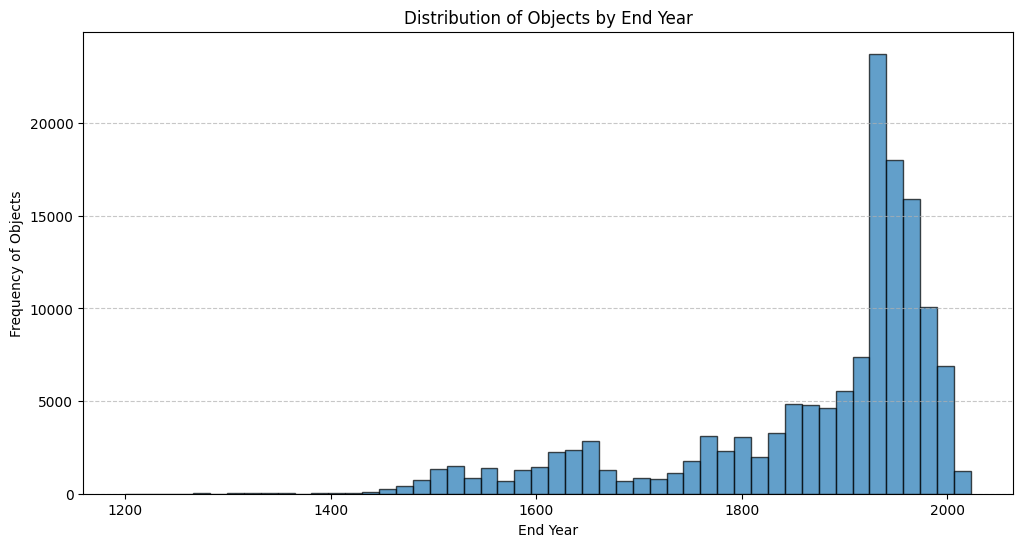

In [45]:
# Assuming the dataframe is named 'objects_df'
objects_df = dataframes.get('objects')[dataframes.get('objects').endyear >= 1200]

# Drop NaN values in 'endyear' column
objects_df = objects_df.dropna(subset=['endyear'])

# Convert 'endyear' to integer
objects_df['endyear'] = objects_df['endyear'].astype(int)

# Plot frequency of objects along the 'endyear'
plt.figure(figsize=(12, 6))
plt.hist(objects_df['endyear'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('End Year')
plt.ylabel('Frequency of Objects')
plt.title('Distribution of Objects by End Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary
#### This dataset is well-structured and requires minimal preprocessing before being loaded into a database. While certain fields contain duplicate values, these can be effectively managed through appropriate filtering criteria. A thorough exploratory data analysis (EDA) has confirmed that no additional data cleaning is necessary. However, to ensure data integrity and consistency, specific constraints should be implemented when performing table joins.